In [2]:
import cv2

cap = cv2.VideoCapture(0)
print("Camera opened:", cap.isOpened())
cap.release()

Camera opened: True


In [3]:
import cv2

cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
detector = cv2.CascadeClassifier(cascade_path)

print("Detector loaded:", not detector.empty())

Detector loaded: True


Faces detected: 0


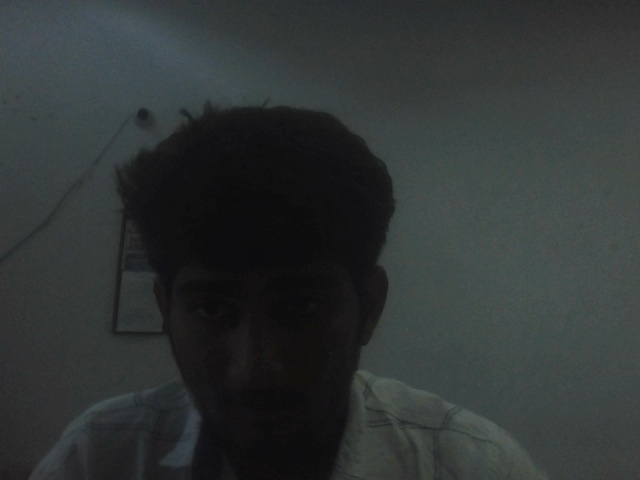

In [4]:
import cv2
from IPython.display import display, Image

cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not grab a frame. Is another app using the camera?")

frame = cv2.flip(frame, 1)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

for i, (x, y, w, h) in enumerate(faces, start=1):
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(frame, f'face {i}', (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

print(f"Faces detected: {len(faces)}")

_, jpg = cv2.imencode('.jpg', frame)
display(Image(data=jpg.tobytes()))

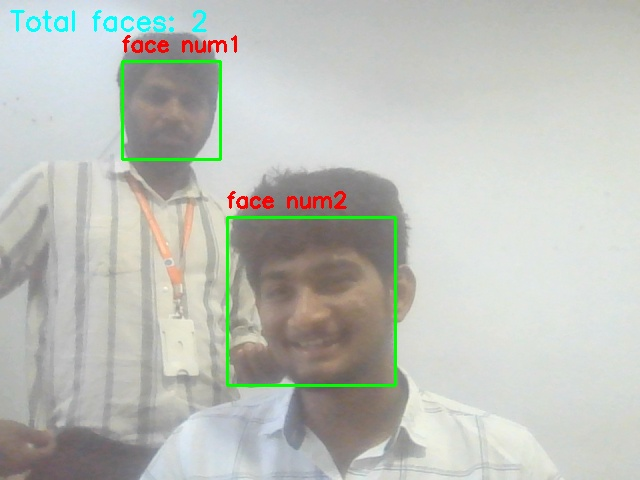

In [ ]:
import cv2
from IPython.display import display, Image, clear_output
import time

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Camera not accessible.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame — stopping.")
            break

        frame = cv2.flip(frame, 1)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        for i, (x, y, w, h) in enumerate(faces, start=1):
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(frame, f'face num{i}', (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        cv2.putText(frame, f'Total faces: {len(faces)}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

        _, jpg = cv2.imencode('.jpg', frame)
        clear_output(wait=True)
        display(Image(data=jpg.tobytes()))

except KeyboardInterrupt:
    print("Stopped by user.")

finally:
    cap.release()
    cv2.destroyAllWindows()
    print("Camera released.")